<a href="https://colab.research.google.com/github/mmadhumitha-22/Birru-Madhumitha/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


========== KPI SUMMARY ==========
Total Sales : $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009


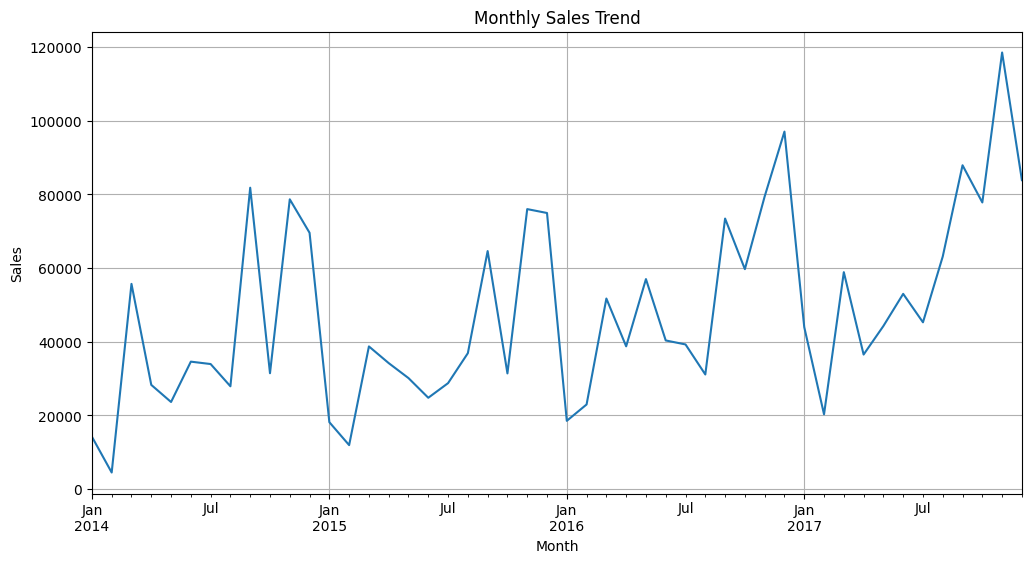

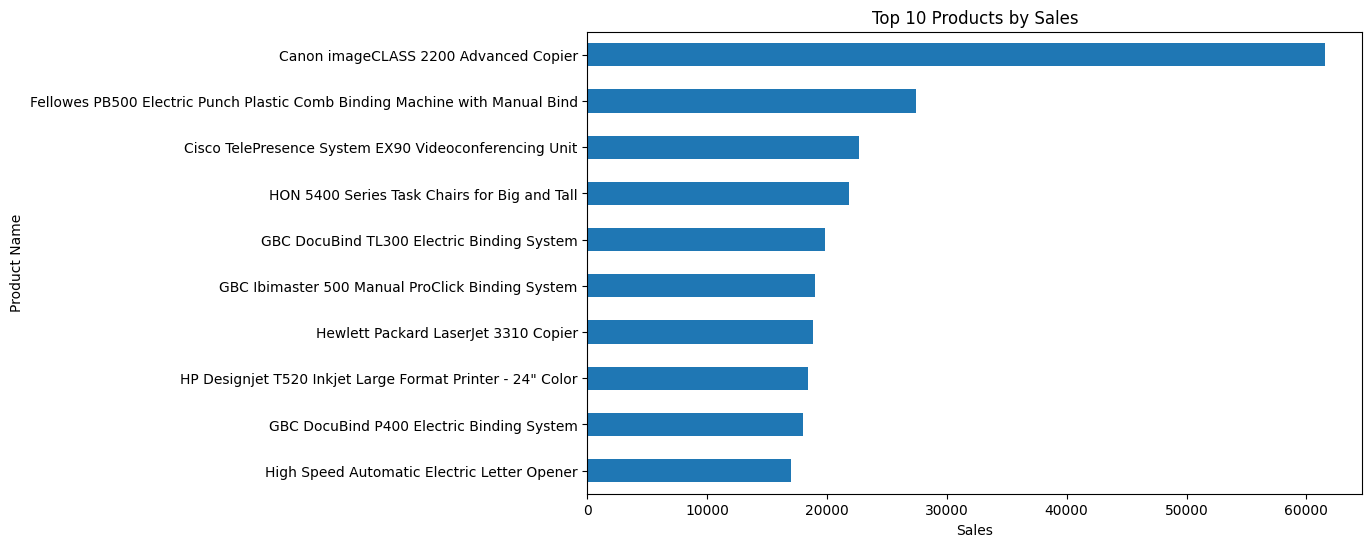

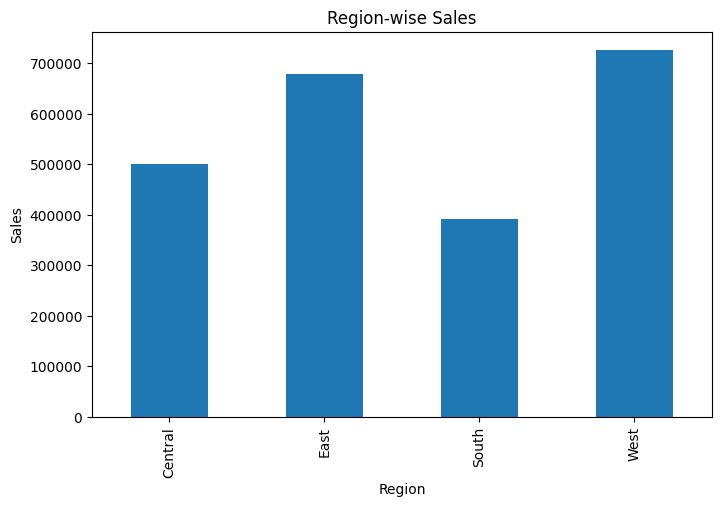

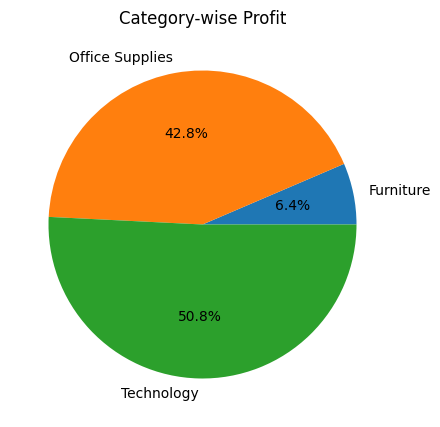


Dashboard Analysis Completed Successfully!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

# Define the path to the zip file and the name of the CSV within it
zip_file_path = '/content/Sample - Superstore.csv.zip'
csv_file_name = 'Sample - Superstore.csv'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Load dataset, specifying 'latin1' encoding to handle UnicodeDecodeError
df = pd.read_csv(f'/content/{csv_file_name}', encoding='latin1')

# Convert Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# ==============================
# KPI SECTION
# ==============================

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("========== KPI SUMMARY ==========")
print(f"Total Sales : ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")

# ==============================
# MONTHLY SALES TREND
# ==============================

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# ==============================
# TOP 10 PRODUCTS
# ==============================

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.show()

# ==============================
# REGION-WISE SALES
# ==============================

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title('Region-wise Sales')
plt.ylabel('Sales')
plt.show()

# ==============================
# CATEGORY-WISE PROFIT
# ==============================

category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(7,5))
category_profit.plot(kind='pie', autopct='%1.1f%%')
plt.title('Category-wise Profit')
plt.ylabel('')
plt.show()

print("\nDashboard Analysis Completed Successfully!")